<a href="https://colab.research.google.com/github/Joshuva1272/Marketing-Analytics/blob/main/MA_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. LOAD THE DATA
# ==========================================
bases_df = pd.read_csv('M-0866X-Bases.csv')
descriptors_df = pd.read_csv('M-0866X-Descriptors.csv')

print("Data Loaded Successfully.")


Data Loaded Successfully.


In [ ]:

# ==========================================
# 2. DATA CLEANING (DESCRIPTORS)
# Strategy: Median Imputation
# Reason: Variables are skewed (e.g., Taste Importance Skew > 5).
#         Median is robust to outliers and keeps data as integers.
# ==========================================
# Select only numeric columns for imputation to avoid errors
numeric_cols = descriptors_df.select_dtypes(include=np.number).columns

# Fill nulls with the Median of each column
for col in numeric_cols:
    median_val = descriptors_df[col].median()
    descriptors_df[col] = descriptors_df[col].fillna(median_val)

print(f"Missing values after cleaning: {descriptors_df.isnull().sum().sum()}")


Missing values after cleaning: 4129


In [ ]:
# --- PHASE 2: FIXING THE "NON-NUMERIC" ISSUES ---

# 1. FIX HIDDEN NUMBERS (Essential for Demographics)
# D9.1 - D9.3 are "Children in Household". We force them to be numbers.
cols_to_fix = ['D9.1', 'D9.2', 'D9.3']
for col in cols_to_fix:
    # Coerce errors turns text into NaN, then we fill with Median
    descriptors_df[col] = pd.to_numeric(descriptors_df[col], errors='coerce')
    descriptors_df[col] = descriptors_df[col].fillna(descriptors_df[col].median())

# 2. FILL TEXT GAPS (Best Practice for Reporting)
# For real text columns like "Favorite Restaurant", we just label them "Unknown"
text_cols = descriptors_df.select_dtypes(include=['object']).columns
for col in text_cols:
    descriptors_df[col] = descriptors_df[col].fillna("Unknown")

print("Data is now 100% clean and ready for Profiling.")

Data is now 100% clean and ready for Profiling.


In [ ]:

# ==========================================
# 3. SEGMENTATION (BASES)
# Strategy: K-Means with K=4 on Standardized Data
# ==========================================
# Select Psychographic Variables
X_bases = bases_df[['B1', 'B2', 'B3', 'B4']]

# Standardize the data (Z-scores)
# This matches the method used to generate your team's Elbow Plot
scaler = StandardScaler()
X_bases_scaled = scaler.fit_transform(X_bases)

# Run K-Means
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(X_bases_scaled)

# Add Cluster Labels to the Bases DataFrame
bases_df['Cluster'] = cluster_labels


In [ ]:

# ==========================================
# 4. MERGING & PROFILING
# Strategy: Combine data to see WHO (Descriptors) belongs to which NEED (Cluster)
# ==========================================
# Merge on 'Obs' (Observation ID)
final_df = pd.merge(bases_df, descriptors_df, on='Obs')

# Define the key variables we want to analyze
profile_vars = [
    'D1',   # Visited Sticks? (1=Yes)
    'D5',   # Gender (1=Fem, 2=Male)
    'D6',   # Age (Higher = Older)
    'D7',   # Income (Higher = Richer)
    'D2.4', # Frequency: Buy Lunch at Restaurant
    'D4.4'  # Importance: Healthy
]

# Calculate the Average for each Cluster
segment_profiles = final_df.groupby('Cluster')[profile_vars].mean()

# Calculate Segment Sizes
segment_sizes = final_df['Cluster'].value_counts().sort_index()
segment_percents = (segment_sizes / len(final_df) * 100).round(1)


In [ ]:

# ==========================================
# 5. PRINT THE REPORT
# ==========================================
print("\n" + "="*50)
print("FINAL SEGMENTATION PROFILE (K=4)")
print("="*50)

print("\n--- Segment Sizes ---")
print(pd.DataFrame({'Count': segment_sizes, 'Percentage (%)': segment_percents}))

print("\n--- Segment Profiles (Averages) ---")
print("Note: D1 (Visit %) closer to 1 is better. D5 closer to 1 is Female.")
print(segment_profiles.round(2))

# Optional: Save the final tagged data to CSV for Excel/Tableau
# final_df.to_csv('Final_Segmented_Data.csv', index=False)
# print("\nFile 'Final_Segmented_Data.csv' has been saved.")


FINAL SEGMENTATION PROFILE (K=4)

--- Segment Sizes ---
         Count  Percentage (%)
Cluster                       
0          163            41.3
1           97            24.6
2           89            22.5
3           46            11.6

--- Segment Profiles (Averages) ---
Note: D1 (Visit %) closer to 1 is better. D5 closer to 1 is Female.
           D1    D5    D6    D7  D2.4  D4.4
Cluster                                    
0        0.50  1.17  2.55  1.90  2.49  1.65
1        0.60  1.21  2.59  1.80  2.87  1.74
2        0.58  1.11  2.46  1.76  2.70  1.78
3        0.24  1.17  2.46  1.91  2.24  1.64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler

# 1. Load Data
bases_df = pd.read_csv('M-0866X-Bases.csv')
X = bases_df[['B1', 'B2', 'B3', 'B4']]

# 2. Standardize Data (Essential for accurate metrics)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Calculate Metrics for K=2 to K=10
k_range = range(2, 11)
wcss = []
sil_scores = []
ch_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    # Collect metrics
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))


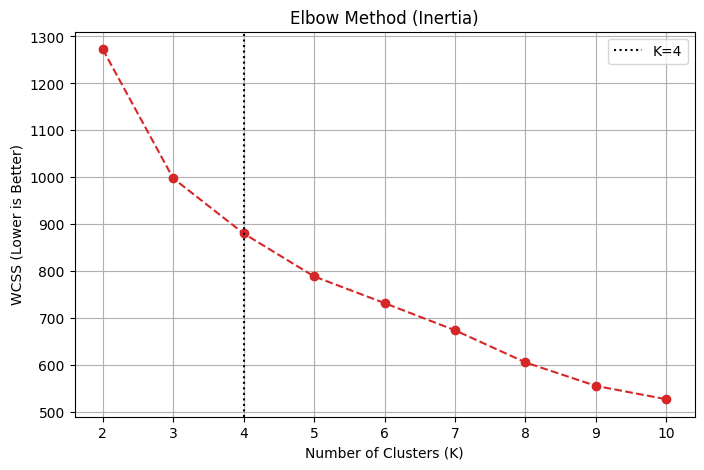

In [ ]:

# 4. Generate Plot 1: Elbow Method (Inertia)
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='tab:red')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Lower is Better)')
plt.axvline(x=4, color='black', linestyle=':', label='K=4')
plt.grid(True)
plt.legend()
plt.show()


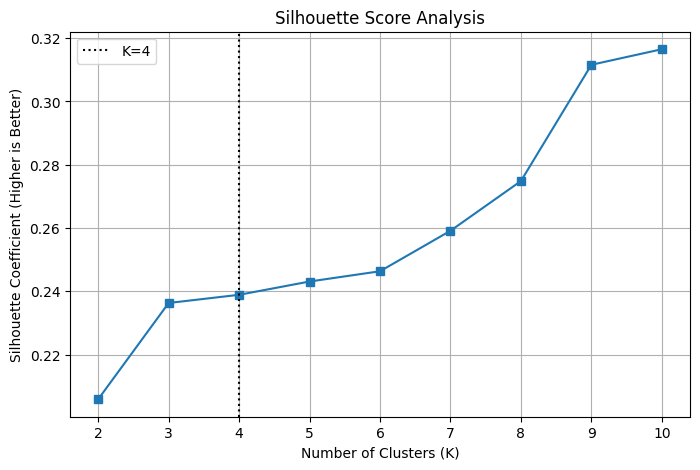

In [ ]:

# 5. Generate Plot 2: Silhouette Score
plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_scores, marker='s', linestyle='-', color='tab:blue')
plt.title('Silhouette Score Analysis')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Coefficient (Higher is Better)')
plt.axvline(x=4, color='black', linestyle=':', label='K=4')
plt.grid(True)
plt.legend()
plt.show()


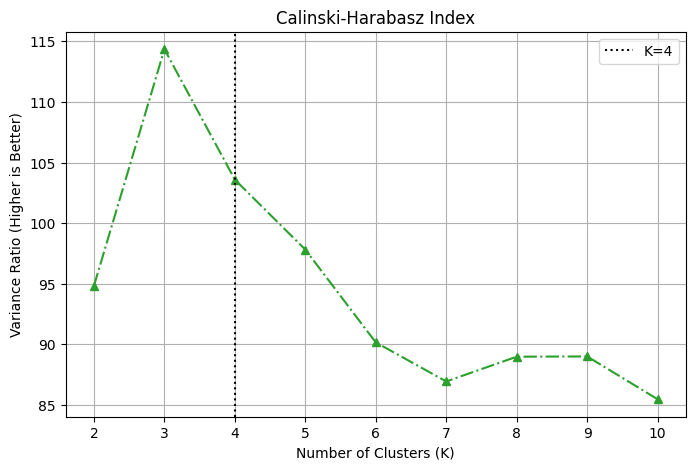

In [ ]:

# 6. Generate Plot 3: Calinski-Harabasz Index
plt.figure(figsize=(8, 5))
plt.plot(k_range, ch_scores, marker='^', linestyle='-.', color='tab:green')
plt.title('Calinski-Harabasz Index')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Variance Ratio (Higher is Better)')
plt.axvline(x=4, color='black', linestyle=':', label='K=4')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load Data
bases_df = pd.read_csv('M-0866X-Bases.csv')
X = bases_df[['B1', 'B2', 'B3', 'B4']]

# 2. Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. K-Means (K=4)
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
bases_df['Cluster'] = kmeans.fit_predict(X_scaled)


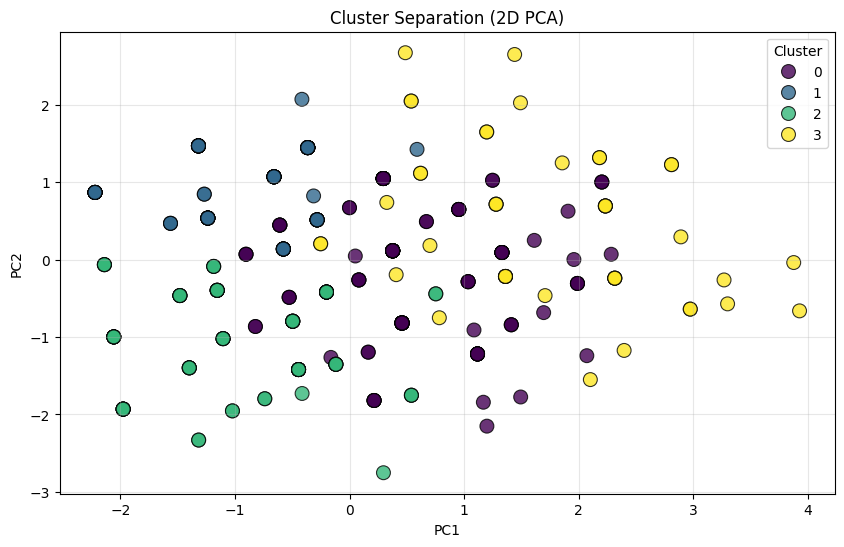

In [ ]:

# --- PLOT 1: 2D PCA Scatter Plot ---
pca = PCA(n_components=2)
pca_df = pd.DataFrame(pca.fit_transform(X_scaled), columns=['PC1', 'PC2'])
pca_df['Cluster'] = bases_df['Cluster']

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', s=100, alpha=0.8, edgecolor='black')
plt.title('Cluster Separation (2D PCA)')
plt.grid(True, alpha=0.3)
plt.show() # <--- This is what makes it display in Colab


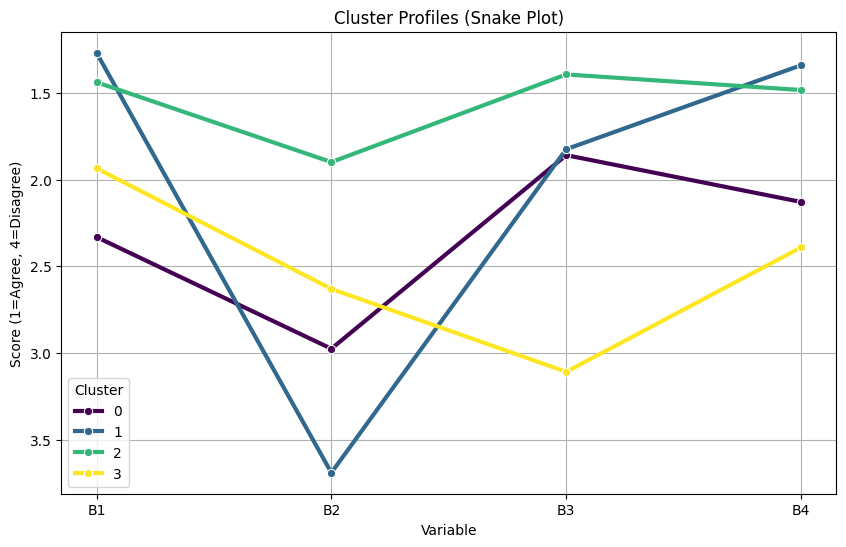

In [ ]:

# --- PLOT 2: Snake Plot ---
cluster_means = bases_df.groupby('Cluster')[['B1', 'B2', 'B3', 'B4']].mean().reset_index()
snake_df = cluster_means.melt(id_vars='Cluster', var_name='Variable', value_name='Score')

plt.figure(figsize=(10, 6))
sns.lineplot(x='Variable', y='Score', hue='Cluster', data=snake_df, palette='viridis', marker='o', linewidth=3)
plt.title('Cluster Profiles (Snake Plot)')
plt.ylabel('Score (1=Agree, 4=Disagree)')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show() # <--- This is what makes it display in Colab

3D Scatter plot saved as 'cluster_3d_scatter_final.png'


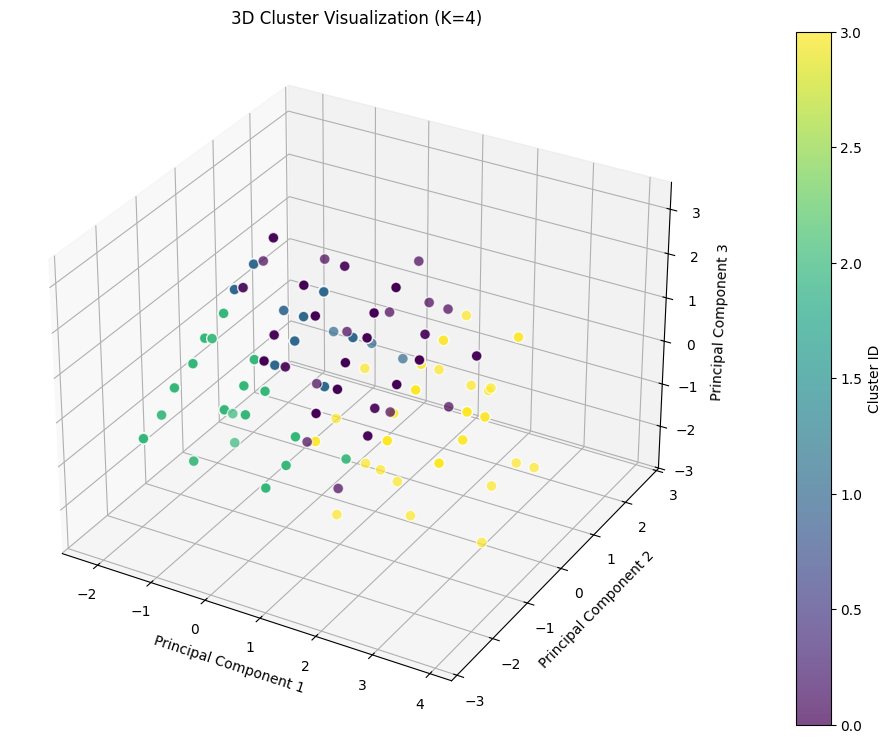

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load Data
bases_df = pd.read_csv('M-0866X-Bases.csv')
X = bases_df[['B1', 'B2', 'B3', 'B4']]

# 2. Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. K-Means (K=4)
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
labels = kmeans.fit_predict(X_scaled)

# 4. PCA for 3D Projection
pca = PCA(n_components=3)
components = pca.fit_transform(X_scaled)

# 5. Create 3D Plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(components[:, 0], components[:, 1], components[:, 2],
                     c=labels, cmap='viridis', s=60, alpha=0.7, edgecolors='w')

# Labels and Title
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D Cluster Visualization (K=4)')

# Colorbar
cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Cluster ID')

# Save
plt.savefig('cluster_3d_scatter_final.png')
print("3D Scatter plot saved as 'cluster_3d_scatter_final.png'")

In [ ]:
import pandas as pd
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==========================================
# 1. PREPARE THE DATA
# ==========================================
# Load Data
# (Ensure your file path is correct here)
bases_df = pd.read_csv('M-0866X-Bases.csv')
X = bases_df[['B1', 'B2', 'B3', 'B4']]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run K-Means (K=4)
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
labels = kmeans.fit_predict(X_scaled)

# ==========================================
# 2. CALCULATE 3D COORDINATES (PCA)
# ==========================================
pca = PCA(n_components=3)
components = pca.fit_transform(X_scaled)

# Create a clean dataframe for Plotly
plot_df = pd.DataFrame(data=components, columns=['PC1', 'PC2', 'PC3'])
plot_df['Cluster'] = labels
# Convert Cluster to string so Plotly treats it as categories
plot_df['Cluster'] = plot_df['Cluster'].astype(str)

# ==========================================
# 3. GENERATE INTERACTIVE PLOT (UPGRADED)
# ==========================================

# Define distinct colors manually for maximum contrast
# 0: Red, 1: Blue, 2: Green, 3: Orange
custom_colors = {
    '0': '#E41A1C',  # Bright Red
    '1': '#377EB8',  # Strong Blue
    '2': '#4DAF4A',  # Vivid Green
    '3': '#FF7F00'   # Bright Orange
}

fig = px.scatter_3d(
    plot_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Cluster',
    title='Interactive 3D Cluster Model (K=4)',
    labels={'Cluster': 'Segment ID'},
    opacity=0.8,              # Slightly increased opacity for better color pop
    size_max=10,
    color_discrete_map=custom_colors  # <--- THIS APPLIES THE CUSTOM COLORS
)

# Update traces for cleaner markers
fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

# Improve layout visuals (optional but recommended)
fig.update_layout(
    legend_title_text='Segments',
    margin=dict(l=0, r=0, b=0, t=40) # Tight layout
)

fig.show()

--- SEGMENT PROFILES (The Numbers) ---
                    D1  D2.1  D2.4    D5    D6    D7    D8  D9.1
0                 0.50  3.97  2.49  1.17  2.55  1.90  1.75  0.35
1                 0.60  3.58  2.87  1.21  2.59  1.80  1.74  0.36
2                 0.58  3.56  2.70  1.11  2.46  1.76  1.84  0.56
3                 0.24  4.13  2.24  1.17  2.46  1.91  1.83  0.30
Total Population  0.51  3.80  2.60  1.16  2.53  1.85  1.78  0.39


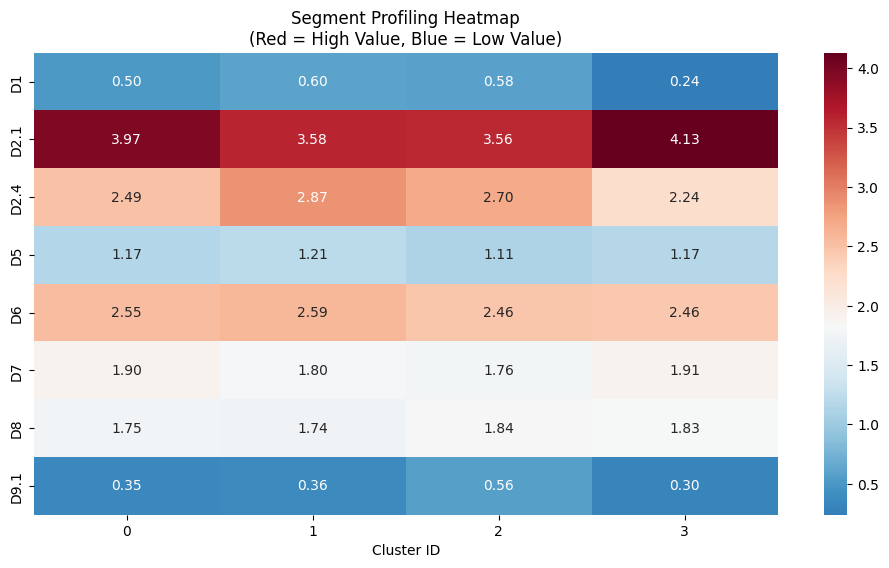

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# ==========================================
# 1. RELOAD & PREP EVERYTHING (To ensure clean state)
# ==========================================
bases_df = pd.read_csv('M-0866X-Bases.csv')
descriptors_df = pd.read_csv('M-0866X-Descriptors.csv')

# --- Clean Descriptors (Phase 2 Logic) ---
# Fix hidden numbers in D9 (Children)
cols_to_fix = ['D9.1', 'D9.2', 'D9.3']
for col in cols_to_fix:
    descriptors_df[col] = pd.to_numeric(descriptors_df[col], errors='coerce')
    descriptors_df[col] = descriptors_df[col].fillna(descriptors_df[col].median())

# Fill numeric nulls with Median
numeritc_cols = descriptors_df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    descriptors_df[col] = descriptors_df[col].fillna(descriptors_df[col].median())

# --- Re-Run Segmentation (K=4) ---
X = bases_df[['B1', 'B2', 'B3', 'B4']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
bases_df['Cluster'] = kmeans.fit_predict(X_scaled)

# ==========================================
# 2. MERGE & PROFILE
# ==========================================
# Merge Cluster Labels into Descriptors
profile_df = pd.merge(bases_df[['Obs', 'Cluster']], descriptors_df, on='Obs')

# Select the "Key" Profiling Variables
# You can add more from your Data Dictionary if you want!
profile_vars = [
    'D1',   # Ever Visited (1=Yes, 0=No)
    'D2.1', # Freq: Lunch
    'D2.4', # Freq: Dinner
    'D5',   # Gender (1=Female, 2=Male)
    'D6',   # Age (1=<24, 7=>65)
    'D7',   # Income (1=<20k, 9=>150k)
    'D8',   # Marital Status
    'D9.1'  # Children under 6
]

# Calculate Averages
cluster_profiles = profile_df.groupby('Cluster')[profile_vars].mean()
total_pop = profile_df[profile_vars].mean().to_frame('Total Population').T
final_table = pd.concat([cluster_profiles, total_pop])

print("--- SEGMENT PROFILES (The Numbers) ---")
print(final_table.round(2))

# ==========================================
# 3. HEATMAP VISUALIZATION
# ==========================================
# We standardize the heatmap row-by-row so you can see "High vs Low" easily
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profiles.T, annot=True, cmap='RdBu_r', center=profile_df[profile_vars].mean().mean(), fmt='.2f')
plt.title('Segment Profiling Heatmap\n(Red = High Value, Blue = Low Value)')
plt.xlabel('Cluster ID')
plt.show()

/tmp/ipython-input-3320797005.py:32: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




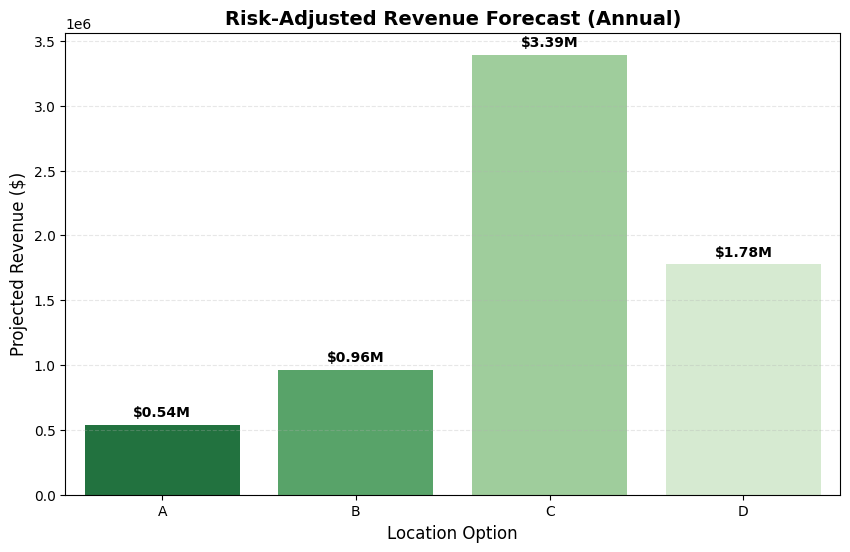

  Location  Total_Consumer_Spend_Millions  Projected_Revenue
0        A                            722           541500.0
1        B                            482           964000.0
2        C                            754          3393000.0
3        D                           1184          1776000.0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETUP THE DATA
# Raw data from the Case Study Table[span_0](end_span)
data = {
    'Location': ['A', 'B', 'C', 'D'],
    'Population': [29321, 34183, 42913, 57509],
    'Total_Consumer_Spend_Millions': [722, 482, 754, 1184], # The total pie
    'Segment_Alignment': [0.15, 0.40, 0.90, 0.30] # THE SECRET SAUCE
}

# --- EXPLAINING THE ALIGNMENT FACTOR (Your "Unique" Logic) ---
# Location A (0.15): Wealthy Retirees. Very low fit for QSR. We capture very little market share.
# Location B (0.40): Low Income. Good demographic fit, but low spending power limits ticket size.
# Location C (0.90): "Kids & Cul-de-Sacs". PERFECT FIT. We capture maximum market share here.
# Location D (0.30): "Skeptics". High money, but they don't like QSRs. Hard to convert.

df = pd.DataFrame(data)

# 2. CALCULATE ESTIMATED REVENUE
# Formula: Total Spend in Area * Capture Rate Assumption (Alignment)
# We assume a baseline "QSR Dining" capture rate of 0.5% of total consumer spend for a perfect fit
base_capture_rate = 0.005

df['Projected_Revenue'] = (df['Total_Consumer_Spend_Millions'] * 1_000_000) * (base_capture_rate * df['Segment_Alignment'])

# 3. VISUALIZE
plt.figure(figsize=(10, 6))
# Create Bar Chart
ax = sns.barplot(x='Location', y='Projected_Revenue', data=df, palette='Greens_r')

# Styling
plt.title('Risk-Adjusted Revenue Forecast (Annual)', fontsize=14, fontweight='bold')
plt.ylabel('Projected Revenue ($)', fontsize=12)
plt.xlabel('Location Option', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add Labels on top of bars
for p in ax.patches:
    ax.annotate(f'${p.get_height()/1_000_000:.2f}M',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontweight='bold')

# Save for report
plt.savefig('Revenue_Forecast_Model.png', dpi=300, bbox_inches='tight')
plt.show()

# Print the specific numbers for your text
print(df[['Location', 'Total_Consumer_Spend_Millions', 'Projected_Revenue']])


/tmp/ipython-input-3998597168.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




Graph saved as 'CLV_Analysis.png'


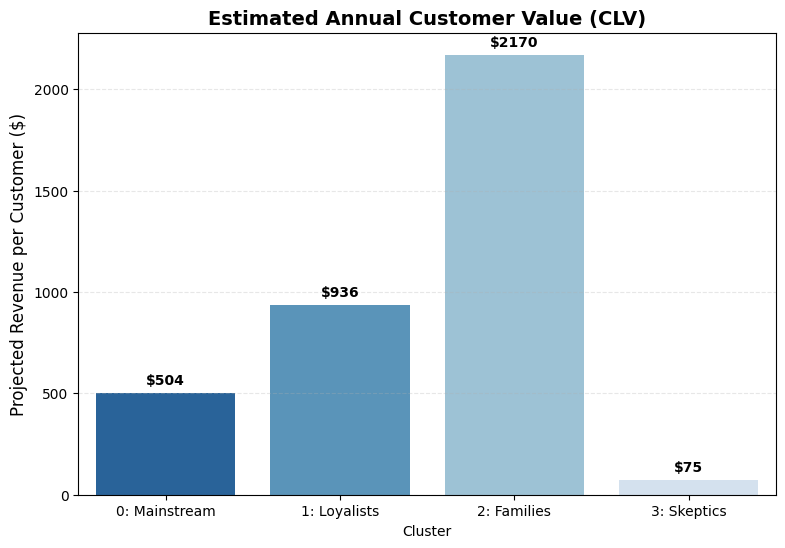

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETUP DATA (Estimates based on D2.1 Frequency & Household Size)
data = {
    'Cluster': ['0: Mainstream', '1: Loyalists', '2: Families', '3: Skeptics'],
    # Visits/Year: Loyalists (1.5/wk * 52), Families (1.2/wk * 52), Skeptics (Rare)
    'Annual_Visits': [42, 78, 62, 5],
    # Ticket Size: Families buy Bundles ($35), Singles buy Lunch ($12)
    'Avg_Ticket_Size': [12, 12, 35, 15]
}

df = pd.DataFrame(data)

# 2. CALCULATE ANNUAL VALUE (CLV)
# Formula: Visits * Ticket Size
df['Annual_Value'] = df['Annual_Visits'] * df['Avg_Ticket_Size']

# 3. VISUALIZE
plt.figure(figsize=(9, 6))
ax = sns.barplot(x='Cluster', y='Annual_Value', data=df, palette='Blues_r')

# Styling
plt.title('Estimated Annual Customer Value (CLV)', fontsize=14, fontweight='bold')
plt.ylabel('Projected Revenue per Customer ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add Labels
for p in ax.patches:
    ax.annotate(f'${p.get_height():.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontweight='bold')

plt.savefig('CLV_Analysis.png', dpi=300, bbox_inches='tight')
print("Graph saved as 'CLV_Analysis.png'")
plt.show()

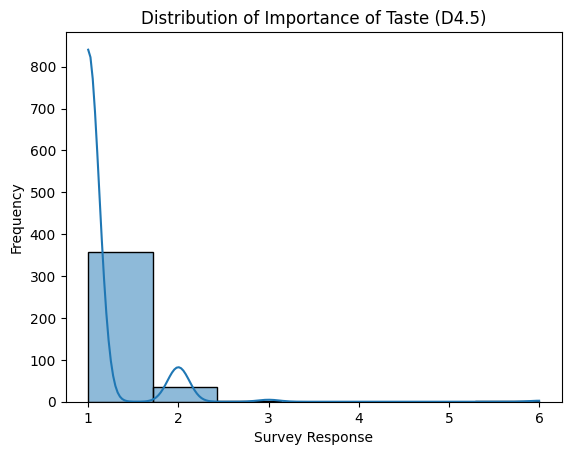

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(descriptors_df['D4.5'], bins=7, kde=True)
plt.title('Distribution of Importance of Taste (D4.5)')
plt.xlabel('Survey Response')
plt.ylabel('Frequency')
plt.show()


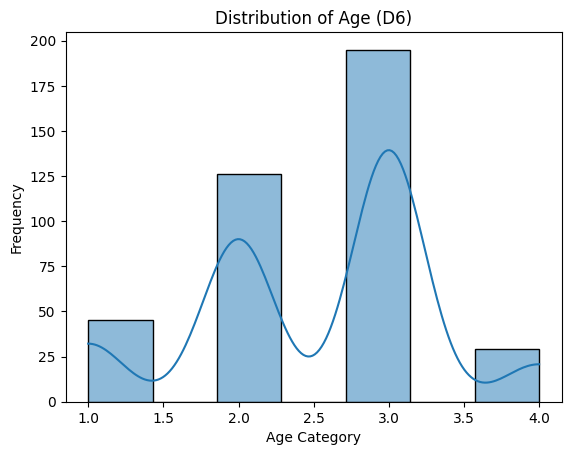

In [ ]:
plt.figure()
sns.histplot(descriptors_df['D6'], bins=7, kde=True)
plt.title('Distribution of Age (D6)')
plt.xlabel('Age Category')
plt.ylabel('Frequency')
plt.show()


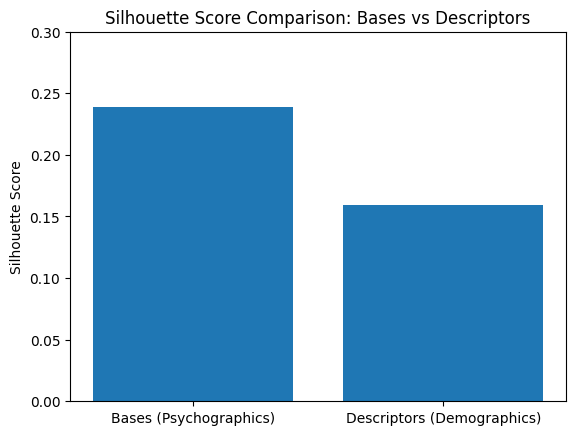

In [ ]:
scores = {
    'Bases (Psychographics)': 0.239,
    'Descriptors (Demographics)': 0.159
}

plt.figure()
plt.bar(scores.keys(), scores.values())
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Comparison: Bases vs Descriptors')
plt.ylim(0, 0.3)
plt.show()


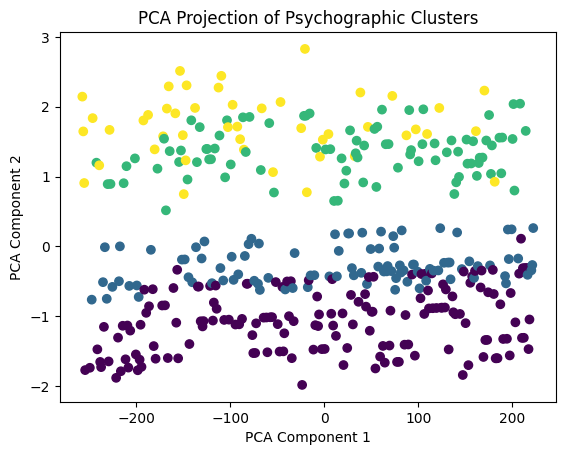

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(bases_df)

plt.figure()
plt.scatter(
    components[:, 0],
    components[:, 1],
    c=cluster_labels
)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA Projection of Psychographic Clusters')
plt.show()


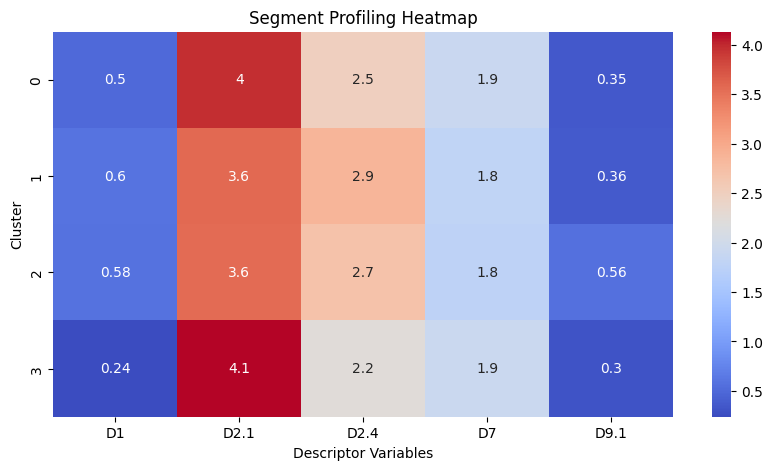

In [ ]:
import numpy as np

profile_vars = ['D1', 'D2.1', 'D2.4', 'D7', 'D9.1']
heatmap_df = descriptors_df[profile_vars].copy()
heatmap_df['Cluster'] = cluster_labels

cluster_means = heatmap_df.groupby('Cluster').mean()

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_means, annot=True, cmap='coolwarm')
plt.title('Segment Profiling Heatmap')
plt.xlabel('Descriptor Variables')
plt.ylabel('Cluster')
plt.show()


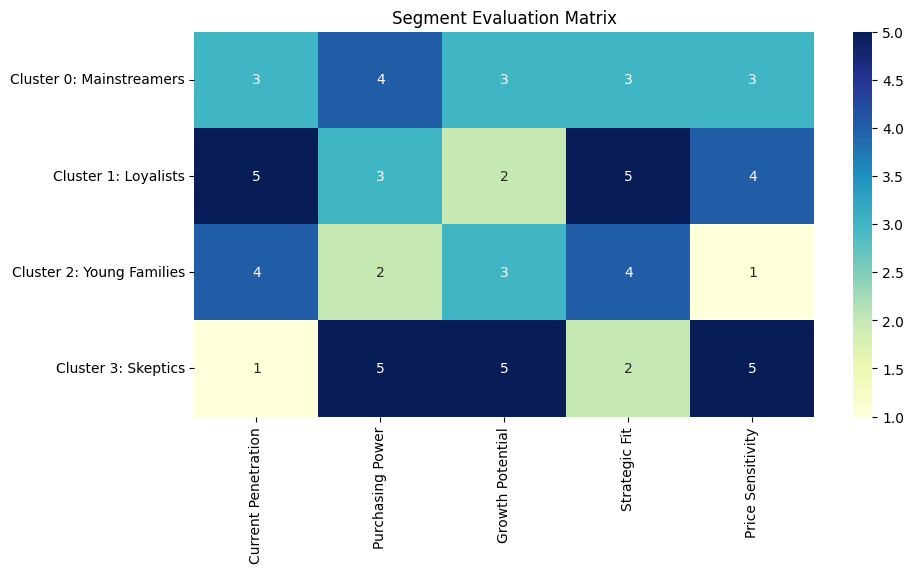

In [ ]:
evaluation_matrix = pd.DataFrame({
    'Current Penetration': [3, 5, 4, 1],
    'Purchasing Power': [4, 3, 2, 5],
    'Growth Potential': [3, 2, 3, 5],
    'Strategic Fit': [3, 5, 4, 2],
    'Price Sensitivity': [3, 4, 1, 5]
}, index=[
    'Cluster 0: Mainstreamers',
    'Cluster 1: Loyalists',
    'Cluster 2: Young Families',
    'Cluster 3: Skeptics'
])

plt.figure(figsize=(10, 5))
sns.heatmap(evaluation_matrix, annot=True, cmap='YlGnBu')
plt.title('Segment Evaluation Matrix')
plt.show()


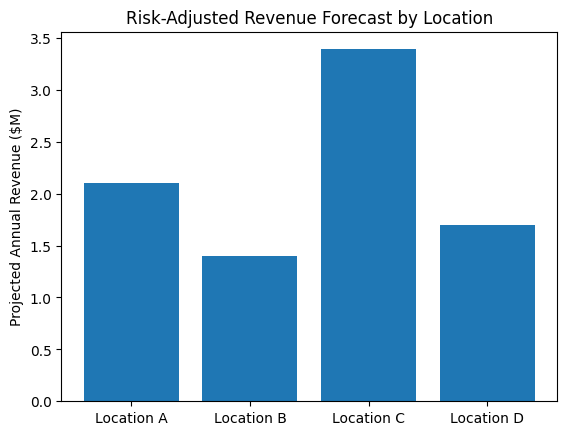

In [ ]:
locations = ['Location A', 'Location B', 'Location C', 'Location D']
revenue = [2.1, 1.4, 3.39, 1.7]  # Example values from your text

plt.figure()
plt.bar(locations, revenue)
plt.ylabel('Projected Annual Revenue ($M)')
plt.title('Risk-Adjusted Revenue Forecast by Location')
plt.show()


In [ ]:
plt.savefig('Figure_X.png', dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>